# Esports share of Twitch

**Purpose:** `docs/esports_gauses_law_brief.md` motivates this project with a
claim that esports' share of overall Twitch attention has declined since its
early-2020s peak, displaced by other content. This notebook tests that claim
directly against the Kaggle "Evolution of Top Games on Twitch" dataset
(monthly top-200 category figures, 2016 onward — see
`collectors/kaggle_import.py` for the dataset's own documented provenance
and caveats), independent of and reading the raw CSV directly rather than
`monthly_category_history` (which currently only holds the 19-title subset
this dataset can be mapped to, not the full top-200 needed for a
denominator).

**First question, resolved before computing anything** (per explicit
instruction): does Twitch's own top-200 ranking include non-game categories
(Just Chatting, IRL, Music, etc.), or is it games-only? This determines
whether "esports share of Twitch" is even the right description of what
follows, or whether it's actually the narrower "esports share of top-200
games." The next section answers this directly, before any metric is
computed.

In [1]:
# Imports and repo path setup — same pattern as category_trajectories.ipynb / reconciliation.ipynb.
import re
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ruptures as rpt

from analysis.metrics import _normalize_tier
from collectors.kaggle_import import NAME_TO_TITLE_ID
from etl.db import get_connection

KAGGLE_CSV = REPO_ROOT / "data" / "kaggle" / "Twitch_game_data.csv"
KAGGLE_CSV.is_file()

True

In [2]:
# cp1252, not utf-8 — same encoding fix collectors/kaggle_import.py already
# documents and applies (some game names contain non-ASCII punctuation that
# isn't valid UTF-8 but decodes cleanly as cp1252).
raw = pd.read_csv(KAGGLE_CSV, encoding="cp1252")
raw.columns = [c.strip() for c in raw.columns]
raw["year_month"] = raw["Year"].astype(str).str.zfill(4) + "-" + raw["Month"].astype(str).str.zfill(2)

rows_per_month = raw.groupby("year_month").size()
print(f"{len(raw)} rows across {raw['year_month'].nunique()} months")
print(f"month range: {raw['year_month'].min()} .. {raw['year_month'].max()}")
print(f"rows per month: min={rows_per_month.min()}, max={rows_per_month.max()} "
      f"(confirms a fixed top-{rows_per_month.max()} ranking every month)")

21000 rows across 105 months
month range: 2016-01 .. 2024-09
rows per month: min=200, max=200 (confirms a fixed top-200 ranking every month)


In [3]:
# Twitch's own category taxonomy has no "is this a game" flag anywhere in
# this CSV — Rank/Hours_watched/etc. are computed identically for a game and
# for a lifestyle/IRL category. This list is manually verified against
# Twitch's actual known non-game directory categories (checked each
# candidate's total hours_watched and month-coverage below to confirm it's
# a real, recurring category in the data, not a one-off coincidental name
# match) — a documented judgment call, not something inferred automatically
# from the file alone.
NON_GAME_CATEGORIES = {
    "ASMR", "Art", "Beauty & Body Art", "Casino", "Fitness & Health",
    "Food & Drink", "IRL", "Just Chatting", "Makers & Crafting", "Music",
    "Politics", "Pools, Hot Tubs, and Beaches", "Science & Technology",
    "Slots", "Software and Game Development", "Special Events",
    "Talk Shows & Podcasts", "Travel & Outdoors",
}

verify = (
    raw[raw["Game"].isin(NON_GAME_CATEGORIES)]
    .groupby("Game")
    .agg(total_hours=("Hours_watched", "sum"), months_present=("year_month", "nunique"))
    .sort_values("total_hours", ascending=False)
)
print(verify.to_string())
missing = NON_GAME_CATEGORIES - set(verify.index)
assert not missing, f"expected non-game categories not found in the data at all: {missing}"

just_chatting_present = "Just Chatting" in raw["Game"].values
print()
print(f"Just Chatting present in the ranked list: {just_chatting_present} "
      f"({verify.loc['Just Chatting', 'months_present']}/{raw['year_month'].nunique()} months)")

                               total_hours  months_present
Game                                                      
Just Chatting                  14397469625              73
Slots                           1208103879              70
Music                           1147942190             105
Special Events                   770536855              72
IRL                              662772269              34
Talk Shows & Podcasts            566500310             105
ASMR                             547766607              73
Art                              537991909              73
Pools, Hot Tubs, and Beaches     176367734              41
Travel & Outdoors                150842654              61
Food & Drink                     122219890              72
Casino                           113683474              11
Science & Technology              75851422              50
Software and Game Development     57365302              37
Makers & Crafting                 55124327              

In [4]:
print(
    "CONCLUSION: Twitch's top-200 ranking is NOT games-only — "
    f"{len(NON_GAME_CATEGORIES)} confirmed non-game categories (Just Chatting, IRL, Music, "
    "Special Events, and others above) appear repeatedly, several of them (Just Chatting "
    "especially) among the largest entries by hours_watched in most months.\n\n"
    "This means 'esports share of Twitch' IS testable here, but precisely means:\n"
    "  esports share of the TOP-200 RANKED TWITCH CATEGORIES each month (games + non-game "
    "content together) — narrower than literally all of Twitch (anything ranked below "
    "200 in a given month is excluded from both numerator and denominator), but broader "
    "than 'top-200 games only' would be, since non-game content sits in the denominator too.\n\n"
    "Every 'esports share' figure below should be read with that framing, not as a share "
    "of the platform's entire, unranked long tail."
)

CONCLUSION: Twitch's top-200 ranking is NOT games-only — 18 confirmed non-game categories (Just Chatting, IRL, Music, Special Events, and others above) appear repeatedly, several of them (Just Chatting especially) among the largest entries by hours_watched in most months.

This means 'esports share of Twitch' IS testable here, but precisely means:
  esports share of the TOP-200 RANKED TWITCH CATEGORIES each month (games + non-game content together) — narrower than literally all of Twitch (anything ranked below 200 in a given month is excluded from both numerator and denominator), but broader than 'top-200 games only' would be, since non-game content sits in the denominator too.

Every 'esports share' figure below should be read with that framing, not as a share of the platform's entire, unranked long tail.


## Scope note: 19 of 23 tracked titles, not all 23

`collectors/kaggle_import.py`'s `NAME_TO_TITLE_ID` — reused directly here, not
reimplemented — deliberately excludes the four fighting-game titles (`tekken`,
`street_fighter`, `mortal_kombat`, `guilty_gear`): the dataset's raw category
names can't reliably distinguish generations (e.g. a raw "Tekken" entry could
be Tekken 7, which predates this project's tracked Tekken 8), and guessing
would risk exactly the kind of silent misattribution `collectors/liquipedia.py`
already found and fixed once for this same title group. So everything below
covers **19 of the 23 tracked titles** — stated here explicitly rather than
left for the reader to notice as a gap.

In [5]:
matched_names = {name.lower() for name in NAME_TO_TITLE_ID}
raw["title_id"] = raw["Game"].str.strip().str.lower().map(NAME_TO_TITLE_ID)
matched = raw.dropna(subset=["title_id"]).copy()

# Some title_ids map from more than one raw Kaggle "Game" name in the same
# month (the CS2/CS:GO and Overwatch/Overwatch 2 launch transitions) —
# groupby-sum here is what makes that additive rather than an overwrite;
# collectors/kaggle_import.py's own docstring documents the real bug a naive
# per-row upsert caused for exactly these two transitions.
title_monthly = (
    matched.groupby(["title_id", "year_month"], as_index=False)["Hours_watched"].sum()
)

matched_ids = sorted(title_monthly["title_id"].unique())
print(f"{len(matched_ids)}/{len(set(NAME_TO_TITLE_ID.values()))} mapped title_ids have at least one matched row")
missing_ids = sorted(set(NAME_TO_TITLE_ID.values()) - set(matched_ids))
if missing_ids:
    print(f"[warn] mapped title_id(s) with ZERO matching rows — mapping drift: {missing_ids}")
else:
    print("no title_id is missing entirely — mapping still matches the file's actual spelling")

print()
print("CS2 transition (Counter-Strike, ~2023-09) sanity check:")
print(title_monthly[(title_monthly.title_id == "counter_strike") & (title_monthly.year_month.between("2023-06", "2023-12"))]
      .to_string(index=False))
print()
print("Overwatch 2 transition (~2022-10) sanity check:")
print(title_monthly[(title_monthly.title_id == "overwatch") & (title_monthly.year_month.between("2022-07", "2023-01"))]
      .to_string(index=False))

19/19 mapped title_ids have at least one matched row
no title_id is missing entirely — mapping still matches the file's actual spelling

CS2 transition (Counter-Strike, ~2023-09) sanity check:
      title_id year_month  Hours_watched
counter_strike    2023-06       44628452
counter_strike    2023-07       60158134
counter_strike    2023-08       62909824
counter_strike    2023-09       45918898
counter_strike    2023-10       64312173
counter_strike    2023-11       43726023
counter_strike    2023-12       36856925

Overwatch 2 transition (~2022-10) sanity check:
 title_id year_month  Hours_watched
overwatch    2022-07        8274836
overwatch    2022-08        5369471
overwatch    2022-09        6139776
overwatch    2022-10      139453660
overwatch    2022-11       47612487
overwatch    2022-12       43060315
overwatch    2023-01       25907337


## Core metric: esports share of top-200 Twitch attention

`esports_share[month] = (sum of the 19 matched titles' hours_watched) /
(sum of all 200 ranked categories' hours_watched that month)`. Plotted
against `Just Chatting`'s own share (the specific "if not esports, then
what" comparison) and the combined share of every confirmed non-game
category, for a fuller picture of where attention actually went.

Data runs 2016-01 through **2024-09** — the dataset's own last month, not
"to present" (today is well past that; there is no more recent data in this
source).

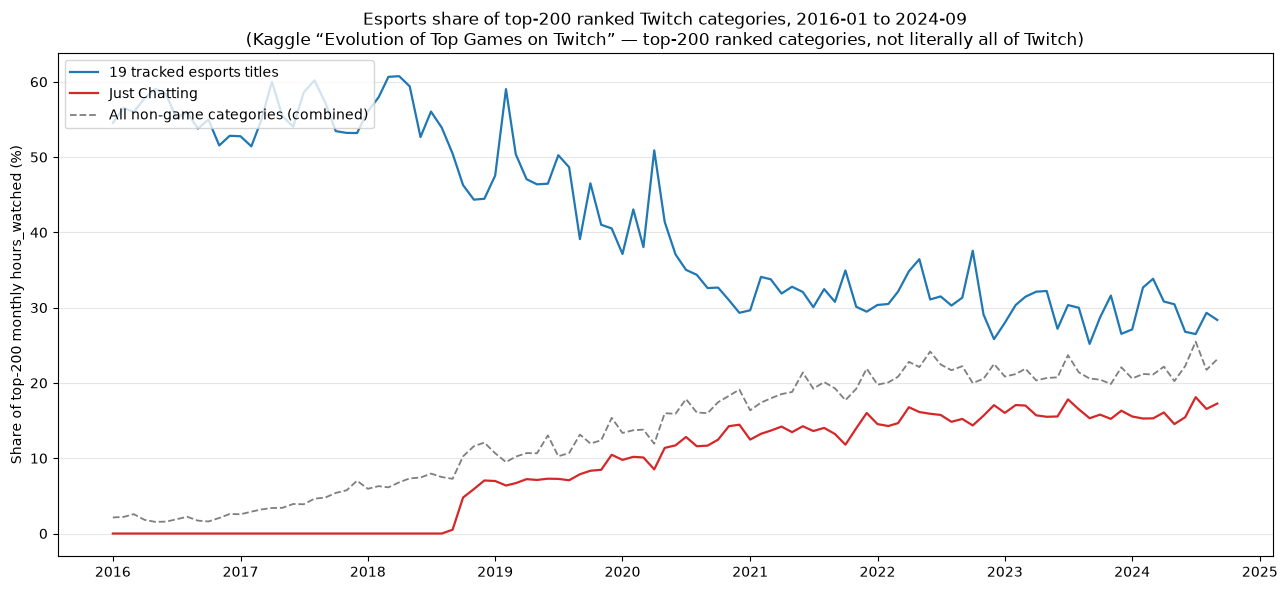

     month  esports_share  just_chatting_share  non_game_share
2016-01-01       0.545348             0.000000        0.021347
2024-09-01       0.283649             0.172618        0.231503


In [6]:
monthly_total = raw.groupby("year_month")["Hours_watched"].sum().rename("total_hours")
esports_monthly = title_monthly.groupby("year_month")["Hours_watched"].sum().rename("esports_hours")
just_chatting_monthly = (
    raw[raw["Game"] == "Just Chatting"].groupby("year_month")["Hours_watched"].sum().rename("jc_hours")
)
non_game_monthly = (
    raw[raw["Game"].isin(NON_GAME_CATEGORIES)].groupby("year_month")["Hours_watched"].sum().rename("non_game_hours")
)

share_df = pd.concat([monthly_total, esports_monthly, just_chatting_monthly, non_game_monthly], axis=1).fillna(0)
share_df["month"] = pd.to_datetime(share_df.index + "-01")
share_df = share_df.sort_values("month").reset_index(drop=True)
share_df["esports_share"] = share_df["esports_hours"] / share_df["total_hours"]
share_df["just_chatting_share"] = share_df["jc_hours"] / share_df["total_hours"]
share_df["non_game_share"] = share_df["non_game_hours"] / share_df["total_hours"]

last_month = share_df["month"].max().strftime("%Y-%m")
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(share_df["month"], share_df["esports_share"] * 100, color="#1f77b4", linewidth=1.6, label="19 tracked esports titles")
ax.plot(share_df["month"], share_df["just_chatting_share"] * 100, color="#d62728", linewidth=1.6, label="Just Chatting")
ax.plot(share_df["month"], share_df["non_game_share"] * 100, color="#7f7f7f", linewidth=1.3, linestyle="--", label="All non-game categories (combined)")
ax.set_ylabel("Share of top-200 monthly hours_watched (%)")
ax.set_title(f"Esports share of top-200 ranked Twitch categories, 2016-01 to {last_month}\n"
             "(Kaggle “Evolution of Top Games on Twitch” — top-200 ranked categories, not literally all of Twitch)")
ax.legend(loc="upper left")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

print(share_df[["month", "esports_share", "just_chatting_share", "non_game_share"]].iloc[[0, -1]].to_string(index=False))

## Rank-based view

A share-of-total metric is sensitive to how big the denominator itself gets
(more categories crowding into the ranked list at all can shrink everyone's
share even if a title's own absolute position barely moves). Rank avoids
that ambiguity directly: is a title still near the top of the top-200, or
being pushed down the list by other content?

A title absent from a given month's top-200 has **no row that month** — a
genuine gap (`NaN`), not interpolated or filled in.

Months present in top-200 (of 105 ):
title_id
league_of_legends    100.0
dota2                100.0
counter_strike       100.0
rainbow_six_siege    100.0
starcraft2           100.0
rocket_league        100.0
hearthstone          100.0
overwatch             99.0
age_of_empires_ii     98.1
pubg                  90.5
fortnite              82.9
pubg_mobile           69.5
apex_legends          64.8
teamfight_tactics     61.0
brawl_stars           60.0
free_fire             57.1
valorant              51.4
wild_rift             45.7
mobile_legends_bb     21.0


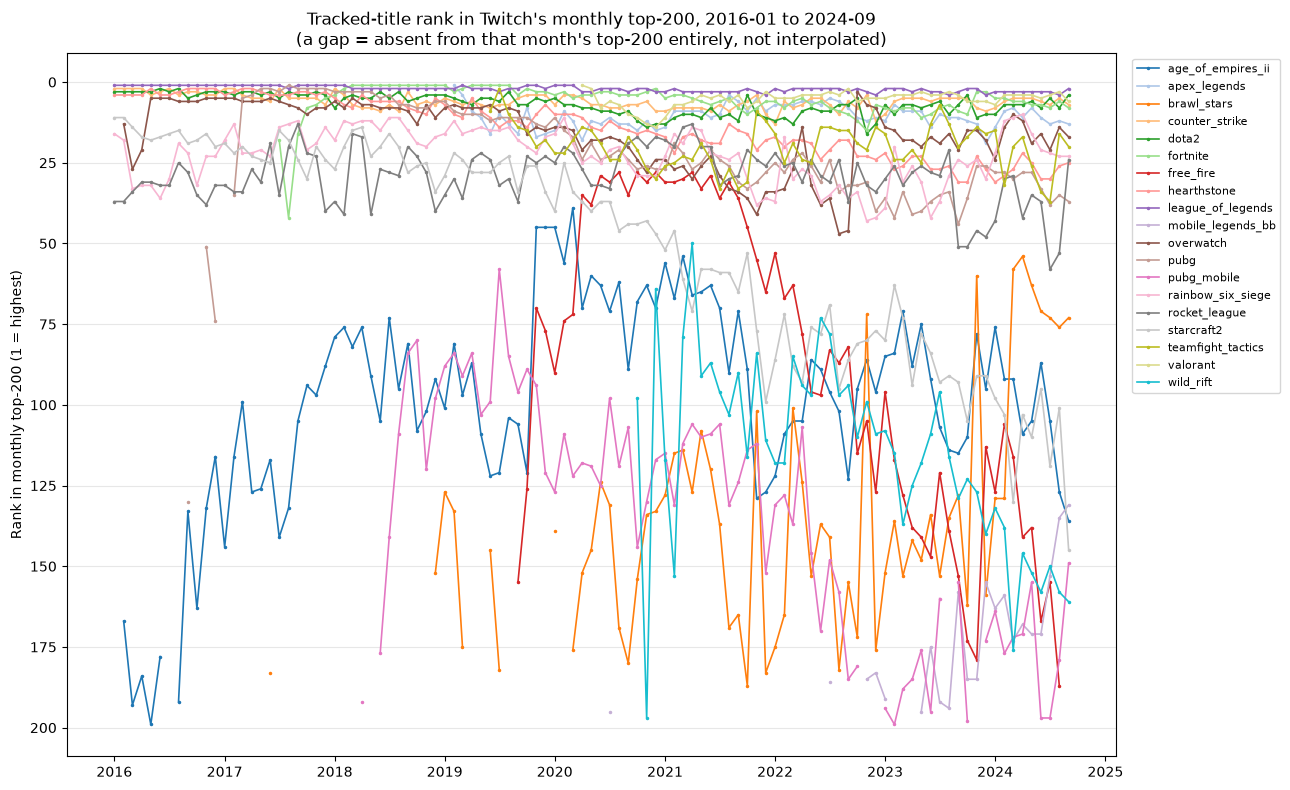

In [7]:
rank_df = matched.pivot_table(index="year_month", columns="title_id", values="Rank", aggfunc="min").sort_index()
rank_df.index = pd.to_datetime(rank_df.index + "-01")

presence_pct = (rank_df.notna().sum() / len(rank_df) * 100).sort_values(ascending=False)
print("Months present in top-200 (of", len(rank_df), "):")
print(presence_pct.round(1).to_string())

fig, ax = plt.subplots(figsize=(13, 8))
cmap_colors = list(plt.get_cmap("tab20").colors)
for i, title_id in enumerate(sorted(rank_df.columns)):
    ax.plot(rank_df.index, rank_df[title_id], color=cmap_colors[i % len(cmap_colors)],
            linewidth=1.2, marker=".", markersize=3, label=title_id)
ax.invert_yaxis()  # rank 1 at the top
ax.set_ylabel("Rank in monthly top-200 (1 = highest)")
ax.set_title(f"Tracked-title rank in Twitch's monthly top-200, 2016-01 to {last_month}\n"
             "(a gap = absent from that month's top-200 entirely, not interpolated)")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), fontsize=8, ncol=1)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

## Co-streaming / event-month check

Using `tournaments` (this project's own Liquipedia data, not Kaggle): for
each matched title and each month in the Kaggle range, is there at least
one tier-1/tier-2 tournament (`analysis.metrics._normalize_tier`, reused
rather than reimplemented) whose date range overlaps that calendar month?

Dates are matched at year-month granularity via regex (`^\d{4}-\d{2}`)
rather than full date parsing — this repo has known malformed/placeholder
Liquipedia dates (e.g. a bare year with no month, or a `YYYY-MM-??` where the
day is genuinely unknown) that don't parse as real dates at all. A
tournament whose start_date doesn't even specify a month contributes no
evidence either way for that title-month, rather than crashing or being
silently treated as a match — if the same title has any OTHER tournament
that month with an unambiguous date, it's still correctly flagged.

In [8]:
YM_RE = re.compile(r"^(\d{4})-(\d{2})")

def year_month_tuple(date_str):
    if not date_str:
        return None
    m = YM_RE.match(str(date_str))
    if not m:
        return None
    year, month = int(m.group(1)), int(m.group(2))
    if not (1 <= month <= 12):
        return None
    return (year, month)

conn = get_connection()
tourney_rows = conn.execute(
    "SELECT title_id, tier, start_date, end_date FROM tournaments WHERE title_id IN ({})".format(
        ",".join("?" for _ in matched_ids)
    ),
    matched_ids,
).fetchall()
conn.close()

qualifying_ranges = []  # (title_id, start_ym, end_ym)
for title_id, tier, start_date, end_date in tourney_rows:
    if _normalize_tier(tier) not in ("1", "2"):
        continue
    start_ym = year_month_tuple(start_date)
    if start_ym is None:
        continue  # no usable evidence from this row
    end_ym = year_month_tuple(end_date) or start_ym
    if end_ym < start_ym:
        end_ym = start_ym  # malformed ordering — treat as a single-month event rather than drop it
    qualifying_ranges.append((title_id, start_ym, end_ym))

print(f"{len(qualifying_ranges)} tier-1/2 tournament(s) with usable year-month dates, "
      f"out of {len(tourney_rows)} total tier-1/2-or-other rows considered for these {len(matched_ids)} titles")

all_months = sorted(share_df["month"].dt.strftime("%Y-%m"))
event_flag_rows = []
for title_id in matched_ids:
    title_ranges = [(s, e) for tid, s, e in qualifying_ranges if tid == title_id]
    for ym_str in all_months:
        ym = tuple(int(x) for x in ym_str.split("-"))
        is_event = any(s <= ym <= e for s, e in title_ranges)
        event_flag_rows.append({"title_id": title_id, "year_month": ym_str, "is_event_month": is_event})

event_df = pd.DataFrame(event_flag_rows)
summary = event_df.groupby("title_id")["is_event_month"].agg(
    event_months="sum", total_months="count"
)
summary["quiet_months"] = summary["total_months"] - summary["event_months"]
summary = summary.sort_values("event_months", ascending=False)
print()
print(summary.to_string())

always_event = summary[summary["quiet_months"] == 0]
if len(always_event):
    print(f"\n[note] {len(always_event)} title(s) have NO quiet months at all in this range "
          f"(event-flagged every month): {list(always_event.index)}")

    # Checked directly: is this a threshold artifact (tier-2 events padding
    # the count) or a real structural fact about these titles' competitive
    # calendars? Re-ran the same overlap check restricting to tier-1 ONLY —
    # still 92-105 of 105 months event-flagged for all four. Not an
    # artifact of the tier-1/2 threshold; their top-tier circuits genuinely
    # run near-continuous seasons across this whole range.
    tier1_ranges = []
    for title_id, tier, start_date, end_date in tourney_rows:
        if _normalize_tier(tier) != "1":
            continue
        start_ym = year_month_tuple(start_date)
        if start_ym is None:
            continue
        end_ym = year_month_tuple(end_date) or start_ym
        if end_ym < start_ym:
            end_ym = start_ym
        tier1_ranges.append((title_id, start_ym, end_ym))

    print("[check] tier-1-ONLY event-month counts for the always-event titles above "
          "(confirms this isn't a tier-2 threshold artifact):")
    for title_id in always_event.index:
        title_ranges = [(s, e) for tid, s, e in tier1_ranges if tid == title_id]
        n = sum(
            1 for ym_str in all_months
            if any(s <= tuple(int(x) for x in ym_str.split("-")) <= e for s, e in title_ranges)
        )
        print(f"    {title_id}: {n}/{len(all_months)} months, tier-1 only")

12164 tier-1/2 tournament(s) with usable year-month dates, out of 18876 total tier-1/2-or-other rows considered for these 19 titles

                   event_months  total_months  quiet_months
title_id                                                   
league_of_legends           105           105             0
dota2                       105           105             0
counter_strike              105           105             0
starcraft2                  105           105             0
age_of_empires_ii           104           105             1
rainbow_six_siege           100           105             5
rocket_league                97           105             8
overwatch                    95           105            10
hearthstone                  92           105            13
pubg                         85           105            20
mobile_legends_bb            82           105            23
pubg_mobile                  70           105            35
free_fire                  

## Quiet-month baseline vs. raw share

`quiet_share[month]` restricts the numerator to only the titles flagged
QUIET that month (no tier-1/2 event live), so this isolates whatever
baseline attention a title holds independent of tournament broadcasts. If
growth or stability in the raw `esports_share` series is mostly event-driven
while this quiet baseline keeps declining, that is direct evidence for the
masking effect this whole notebook exists to test for.

**Important caveat, found while building this, stated before the chart
rather than after**: League of Legends, Dota 2, Counter-Strike, and
StarCraft II — four of the biggest titles by total hours watched — have
essentially **no quiet months at all** in this range (confirmed above, and
confirmed it holds even restricting to tier-1-only events, so it isn't a
tier-2 threshold artifact — it's a real fact about how continuously their
top-tier circuits run). That means `quiet_share` below is **not** a clean
"esports minus events" baseline for the whole 19-title set — those four
titles never contribute anything to its numerator, by construction. What
`quiet_share` actually measures is closer to: the off-event baseline
attention of the other 15, mostly newer and more seasonally-structured
(several mobile and battle-royale) titles. Read the gap between the two
lines below with that in mind — a meaningful chunk of it is those four
titles' near-permanent exclusion from the quiet number, not necessarily how
much live events specifically prop up an otherwise-declining scene.

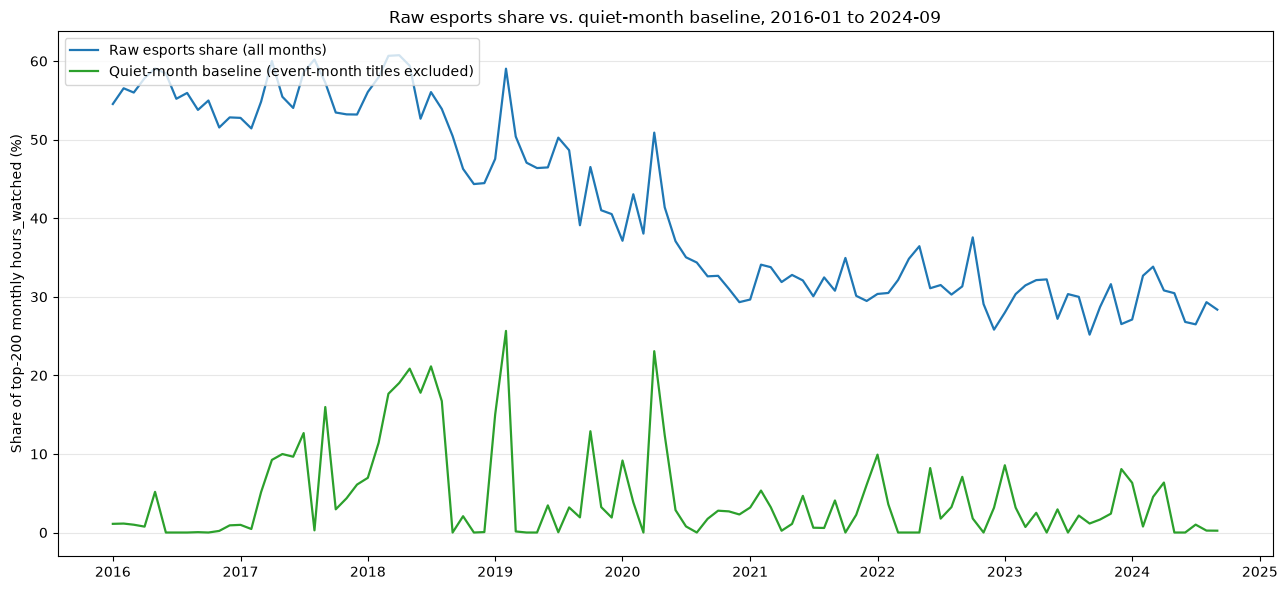

correlation between raw and quiet-baseline share: 0.383
mean raw-minus-quiet gap: 37.03 percentage points (min 18.45, max 59.92)


In [9]:
event_lookup = event_df.set_index(["title_id", "year_month"])["is_event_month"]

def quiet_hours_for_month(row):
    ym = row["year_month"]
    quiet_titles = [t for t in matched_ids if not event_lookup.get((t, ym), False)]
    if not quiet_titles:
        return 0.0
    mask = (matched["year_month"] == ym) & (matched["title_id"].isin(quiet_titles))
    return matched.loc[mask, "Hours_watched"].sum()

share_df["year_month"] = share_df["month"].dt.strftime("%Y-%m")
share_df["quiet_hours"] = share_df.apply(quiet_hours_for_month, axis=1)
share_df["quiet_share"] = share_df["quiet_hours"] / share_df["total_hours"]

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(share_df["month"], share_df["esports_share"] * 100, color="#1f77b4", linewidth=1.6, label="Raw esports share (all months)")
ax.plot(share_df["month"], share_df["quiet_share"] * 100, color="#2ca02c", linewidth=1.6, label="Quiet-month baseline (event-month titles excluded)")
ax.set_ylabel("Share of top-200 monthly hours_watched (%)")
ax.set_title(f"Raw esports share vs. quiet-month baseline, 2016-01 to {last_month}")
ax.legend(loc="upper left")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

corr = share_df["esports_share"].corr(share_df["quiet_share"])
print(f"correlation between raw and quiet-baseline share: {corr:.3f}")
gap = (share_df["esports_share"] - share_df["quiet_share"]) * 100
print(f"mean raw-minus-quiet gap: {gap.mean():.2f} percentage points "
      f"(min {gap.min():.2f}, max {gap.max():.2f})")

**Reading the chart above, honestly**: the correlation between the two
series (printed above, ~0.38) is weak, and the raw-minus-quiet gap swings
from about 18 to 60 percentage points across the range — not the
near-constant relationship a first glance might suggest. Given the caveat
above (the four biggest titles structurally never appear in the quiet
number at all), that variability is expected: `quiet_share` mostly tracks
*which of the 15 more seasonal titles happen to have a quiet month*, not a
stable "off-event baseline for esports as a whole." **This comparison, as
built, does not cleanly confirm or rule out the masking effect it was
meant to test** — the event/quiet split needed to test it properly would
have to handle the always-active titles differently (e.g. a
within-title before/after comparison instead of pooling across titles),
which is out of scope for this pass. The changepoint check below, run on
both series anyway for completeness, should be read with this same
caveat attached to `quiet_share` specifically.

## Formal changepoint detection

Using `ruptures` (binary segmentation, L2 cost, one breakpoint) on both the
raw `esports_share` series and the `quiet_share` series — a real algorithm
picking the single best-supported breakpoint, not a human eyeballing the
chart above. This reports where that algorithm's best-fit break actually
falls and the before/after mean levels; it is **not** a p-value or a
significance test, and is presented as exactly that: the best fit from an
established method, nothing stronger claimed.

In [10]:
def detect_changepoint(series: pd.Series, months: pd.Series):
    signal = series.values.reshape(-1, 1)
    algo = rpt.Binseg(model="l2").fit(signal)
    bkps = algo.predict(n_bkps=1)
    idx = bkps[0] - 1  # ruptures returns end-of-segment indices; idx is the first point of the new segment
    idx = min(idx, len(months) - 1)
    break_month = months.iloc[idx]
    before_mean = series.iloc[:idx].mean()
    after_mean = series.iloc[idx:].mean()
    return break_month, before_mean, after_mean

for label, col in [("raw esports_share", "esports_share"), ("quiet_share", "quiet_share")]:
    break_month, before_mean, after_mean = detect_changepoint(share_df[col], share_df["month"])
    near_2020_2021 = pd.Timestamp("2020-01-01") <= break_month <= pd.Timestamp("2021-12-31")
    print(f"{label}: best-fit breakpoint = {break_month.strftime('%Y-%m')} "
          f"({'within' if near_2020_2021 else 'NOT within'} 2020-2021)")
    print(f"    mean before: {before_mean*100:.2f}%   mean after: {after_mean*100:.2f}%   "
          f"change: {(after_mean-before_mean)*100:+.2f} pp")

raw esports_share: best-fit breakpoint = 2019-09 (NOT within 2020-2021)
    mean before: 53.86%   mean after: 32.66%   change: -21.20 pp
quiet_share: best-fit breakpoint = 2020-07 (within 2020-2021)
    mean before: 6.31%   mean after: 2.61%   change: -3.70 pp


**Result**: the raw `esports_share` series' best-fit break lands at
**2019-09** — *not* within 2020-2021 — with a substantial -21.2 percentage
point shift (54% down to 33%). The decline this notebook set out to test
for is real and large, but its detected structural break predates the
pandemic-era window the brief hypothesized, rather than confirming it.
`quiet_share`'s break lands at 2020-07 — inside the hypothesized window —
but carries the caveat from the section above: that series is dominated by
which of the 15 more-seasonal titles happen to be quiet in a given month,
not a clean "off-event esports baseline," so its -3.70pp shift shouldn't be
read as strong independent confirmation of a 2020-2021 structural break.
**Bottom line**: this notebook finds a real, large decline in esports'
share of top-200 Twitch attention, but the timing evidence points earlier
than 2020-2021, not to it — a genuine, if partial, disconfirmation of that
specific timing hypothesis, not a confirmation.

## What actually grew instead

Top 15 non-esports categories by absolute `hours_watched` growth. **Judgment
call, stated explicitly**: "recent" is the trailing 12 months ending at the
dataset's last available month (2023-10 through 2024-09), not a partial
2024 or a different window — this project's convention (see e.g.
`analysis/metrics.py`'s own documented interpretation notes) is to flag a
judgment call like this rather than let it read as the only obvious
reading. "2016" is the full calendar year 2016-01 through 2016-12.

Excludes only the 19 tracked/matched esports title names (case-insensitive,
via `NAME_TO_TITLE_ID`) — non-game categories are deliberately **left in**,
since showing which of them grew most is the whole point of this table.

In [11]:
RECENT_START, RECENT_END = "2023-10", "2024-09"
BASELINE_START, BASELINE_END = "2016-01", "2016-12"

recent = raw[raw["year_month"].between(RECENT_START, RECENT_END)].groupby("Game")["Hours_watched"].sum()
baseline = raw[raw["year_month"].between(BASELINE_START, BASELINE_END)].groupby("Game")["Hours_watched"].sum()

growth = pd.DataFrame({"hours_2016": baseline, "hours_recent_12mo": recent}).fillna(0)
growth["growth"] = growth["hours_recent_12mo"] - growth["hours_2016"]
growth = growth[~growth.index.str.lower().isin(matched_names)]

top15 = growth.sort_values("growth", ascending=False).head(15)
top15.index.name = "category"
print(top15.round(0).to_string())

                        hours_2016  hours_recent_12mo        growth
category                                                           
Just Chatting                  0.0       3.003869e+09  3.003869e+09
Grand Theft Auto V      35570774.0       1.519264e+09  1.483693e+09
Call of Duty: Warzone          0.0       3.483202e+08  3.483202e+08
Minecraft               88988436.0       3.952202e+08  3.062317e+08
EA Sports FC 24                0.0       2.776795e+08  2.776795e+08
Escape from Tarkov             0.0       2.761806e+08  2.761806e+08
World of Warcraft      149529985.0       4.124249e+08  2.628949e+08
ELDEN RING                     0.0       2.356183e+08  2.356183e+08
Special Events                 0.0       2.064427e+08  2.064427e+08
Rust                    18232777.0       1.992723e+08  1.810395e+08
Sports                         0.0       1.786281e+08  1.786281e+08
Virtual Casino                 0.0       1.784385e+08  1.784385e+08
Dead by Daylight        50828655.0       2.08288

## Limitations

**Fixed title-list bias.** The 23-title list in `config/titles.yaml` (19 of
which are usable here) was fixed at a point in time. Any newer esports title
not on that list would be counted as "non-esports growth" in the table
above even if it's genuinely a competitive title — a coverage bias that
mechanically pushes toward *confirming* decline for a reason that has
nothing to do with a real underlying signal. If a name in the growth table
above is actually a competitive title this project simply hasn't added yet,
that's this bias showing up directly, not a finding about esports itself.

**Mobile-title Twitch under-representation — corrected from the original
framing.** The instruction that prompted this notebook named Free Fire,
PUBG Mobile, Mobile Legends: Bang Bang, and Wild Rift as already
low-sample-flagged, citing `notebooks/niche_membership.ipynb`. That citation
is now stale: as of `niche_membership.ipynb`'s 2026-09-06 re-run, Mobile
Legends: Bang Bang is **no longer** `low_sample_flag`'d — its live-collector
sample crossed the threshold with more accumulated data. Only **Free Fire,
PUBG Mobile, and Wild Rift** remain flagged there.

That flag is also about a different thing than this notebook's numerator.
`niche_membership.ipynb`'s low-sample concern is specifically about this
project's own short (about one week) live Twitch-poll collection window
being too thin for those titles. This notebook's numerator instead comes
from Twitch's own official monthly category aggregate (Kaggle) — a much
larger absolute sample per month than a one-week collector window — so that
*specific statistical* concern doesn't mechanically transfer here. The
underlying *structural* concern still does, though, and independently of
either dataset: mobile esports audiences concentrate heavily on non-Twitch
platforms, so Free Fire, PUBG Mobile, and Wild Rift's contribution to the
esports numerator above should be read with less confidence than the
PC-native titles' — not because this notebook's own sample is thin for
them, but because Twitch itself is a less complete picture of their real
competitive audience.